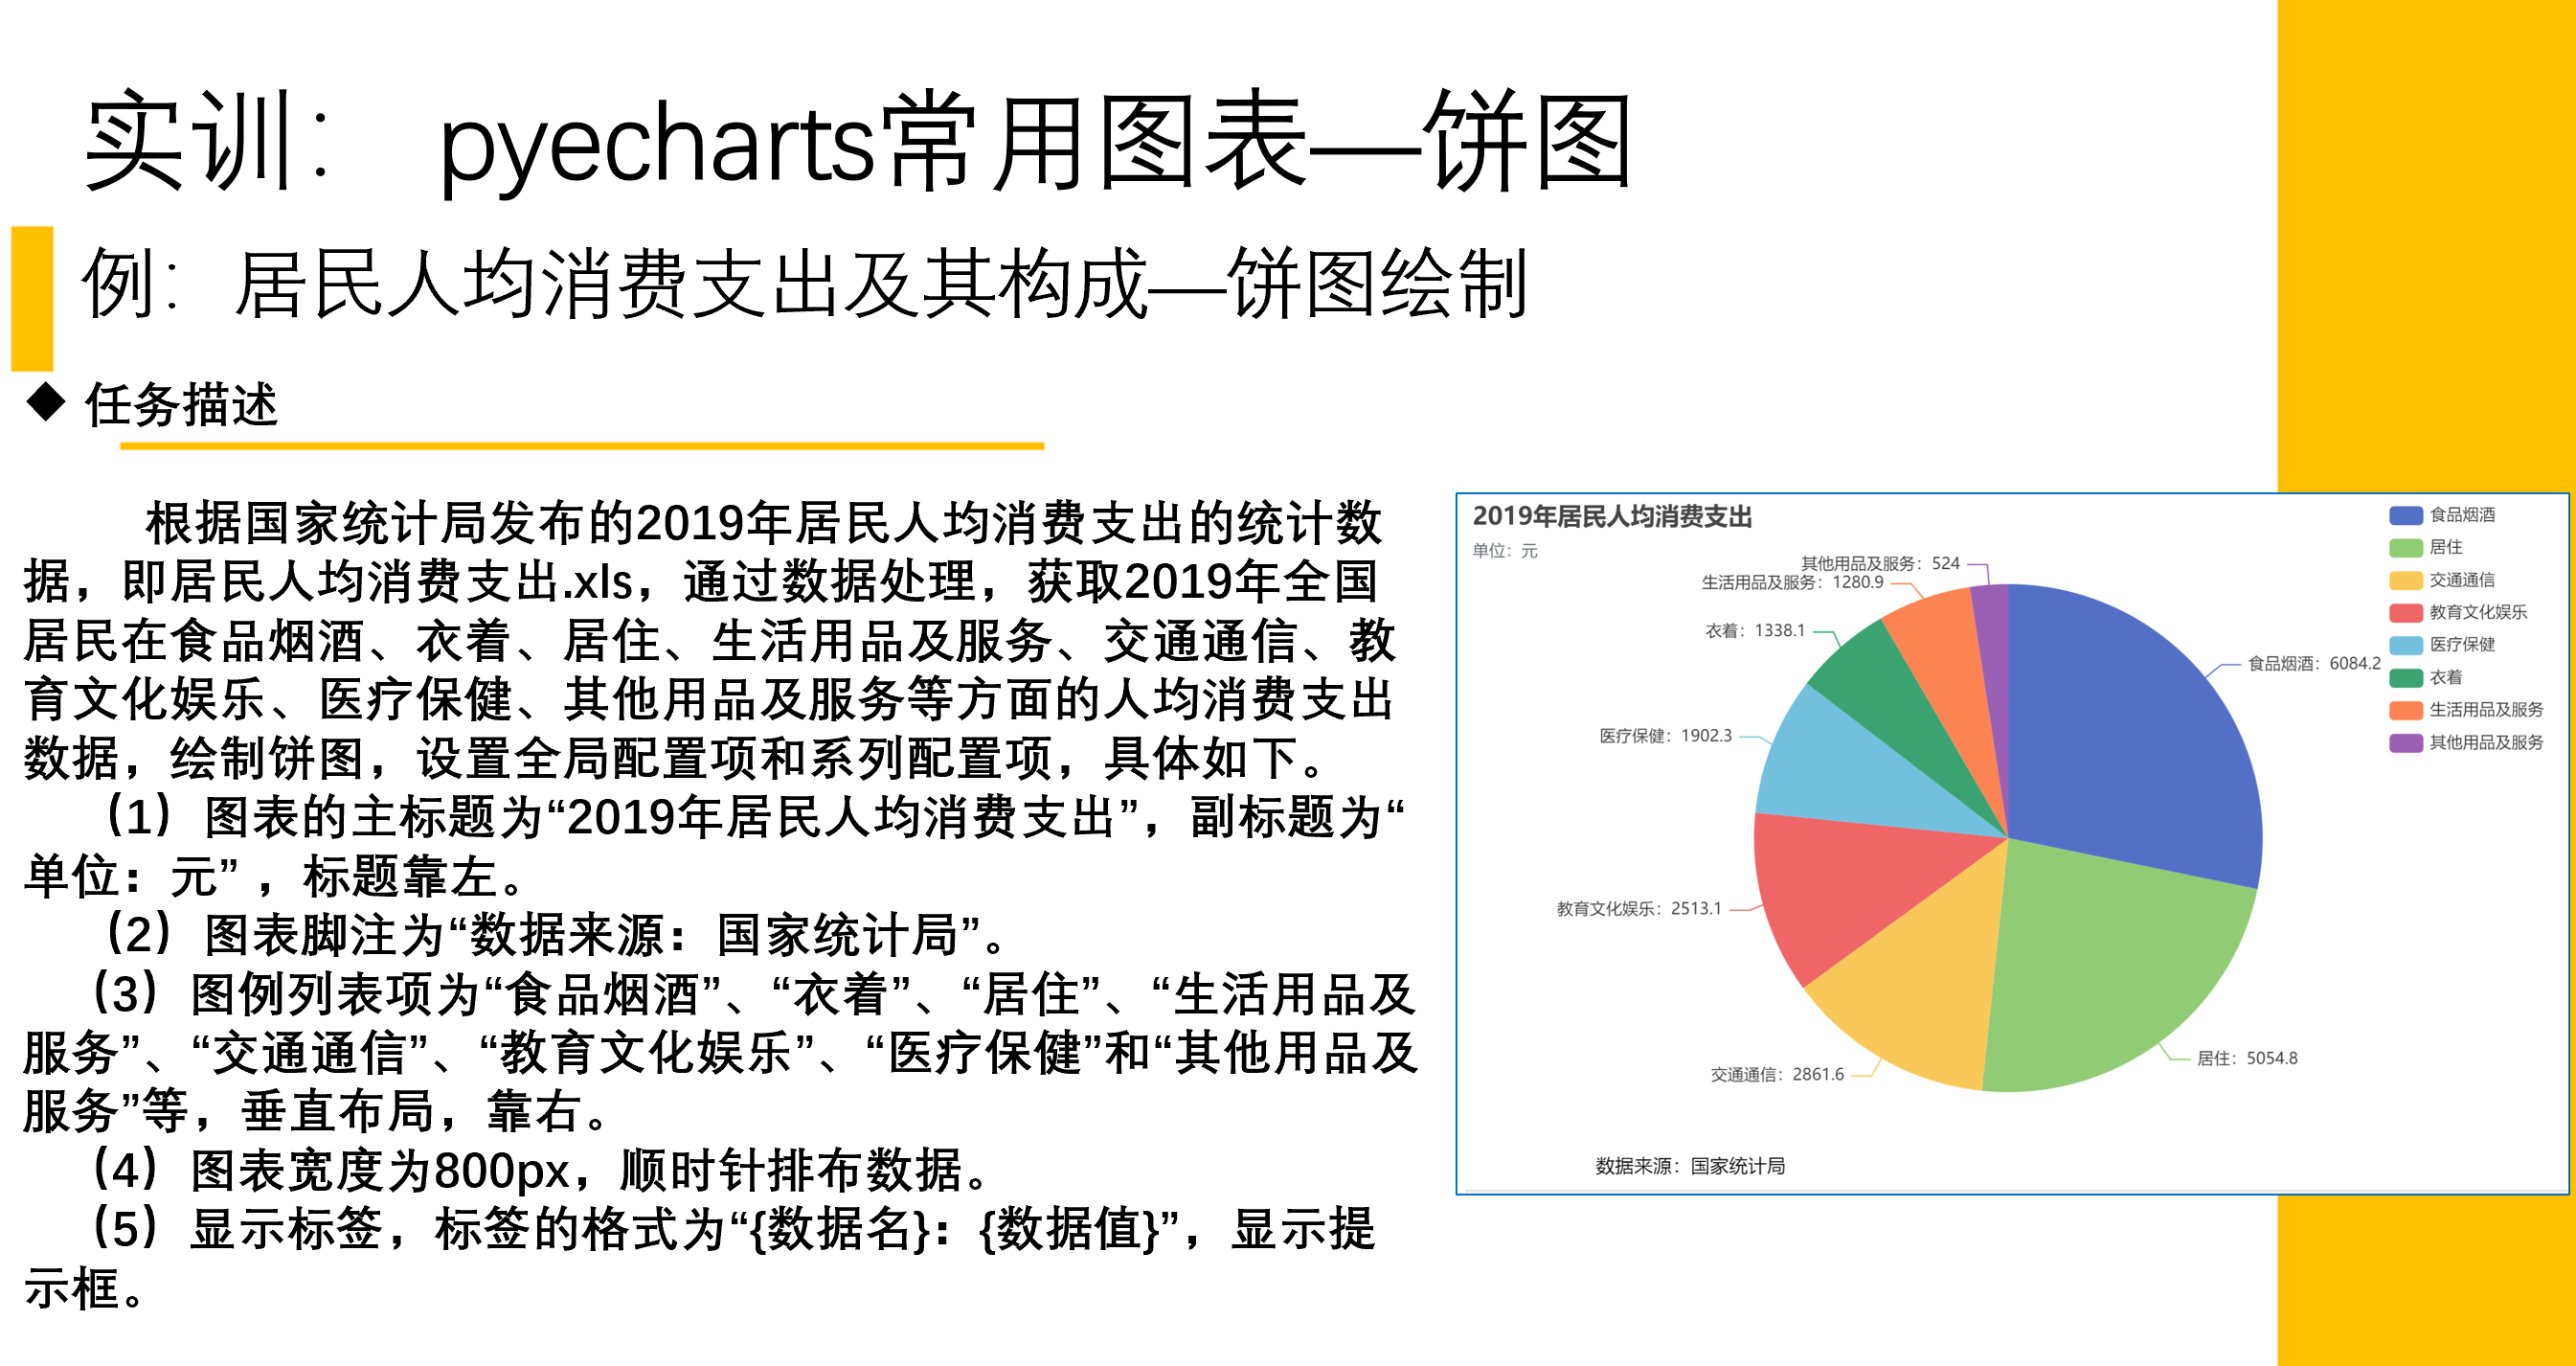

In [35]:
from pyecharts.globals import CurrentConfig, NotebookType
CurrentConfig.NOTEBOOK_TYPE = NotebookType.JUPYTER_LAB

from pyecharts import options as opts
from pyecharts.charts import Pie
import pandas as pd
#导入数据
df = pd.read_excel('c:/dataset/居民人均消费支出.xls',header=1)
df

,地区,消费支出,食品烟酒,衣着,居住,生活用品及服务,交通通信,教育文化娱乐,医疗保健,其他用品及服务
0,全国,21558.9,6084.2,1338.1,5054.8,1280.9,2861.6,2513.1,1902.3,524.0
1,北京,43038.3,8488.5,2229.5,15751.4,2387.3,4979.0,4310.9,3739.7,1151.9
2,天津,31853.6,8983.7,1999.5,6946.1,1956.7,4236.4,3584.4,2991.9,1154.9
3,河北,17987.2,4675.7,1304.8,4301.6,1170.4,2415.7,1984.1,1699.0,435.8
4,山西,15862.6,3997.2,1289.9,3331.6,910.7,1979.7,2136.2,1820.7,396.5
5,内蒙古,20743.4,5517.3,1765.4,3943.7,1185.8,3218.4,2407.7,2108.0,597.1
6,辽宁,22202.8,5956.6,1586.1,4417.0,1275.3,2848.5,2929.3,2434.2,756.0
7,吉林,18075.4,4675.4,1406.8,3351.5,948.3,2518.1,2436.6,2174.0,564.7
8,黑龙江,18111.5,4781.1,1437.6,3314.2,844.8,2317.4,2444.9,2457.1,514.4
9,上海,45605.1,10952.6,2071.8,15046.4,2122.8,5355.7,5495.1,3204.8,1355.9


In [36]:
#获取2019年居民人均消费支出数据
df1 = df.T
df1

,0,1,2,3,4,5,6,7,8,9
地区,全国,北京,天津,河北,山西,内蒙古,辽宁,吉林,黑龙江,上海
消费支出,21558.9,43038.3,31853.6,17987.2,15862.6,20743.4,22202.8,18075.4,18111.5,45605.1
食品烟酒,6084.2,8488.5,8983.7,4675.7,3997.2,5517.3,5956.6,4675.4,4781.1,10952.6
衣着,1338.1,2229.5,1999.5,1304.8,1289.9,1765.4,1586.1,1406.8,1437.6,2071.8
居住,5054.8,15751.4,6946.1,4301.6,3331.6,3943.7,4417,3351.5,3314.2,15046.4
生活用品及服务,1280.9,2387.3,1956.7,1170.4,910.7,1185.8,1275.3,948.3,844.8,2122.8
交通通信,2861.6,4979,4236.4,2415.7,1979.7,3218.4,2848.5,2518.1,2317.4,5355.7
教育文化娱乐,2513.1,4310.9,3584.4,1984.1,2136.2,2407.7,2929.3,2436.6,2444.9,5495.1
医疗保健,1902.3,3739.7,2991.9,1699,1820.7,2108,2434.2,2174,2457.1,3204.8
其他用品及服务,524,1151.9,1154.9,435.8,396.5,597.1,756,564.7,514.4,1355.9


In [37]:
df2 = df1.iloc[2:,[0]]  #不包含0，1行，从食品烟酒开始筛选；获取0列数据，
df2

,0
食品烟酒,6084.2
衣着,1338.1
居住,5054.8
生活用品及服务,1280.9
交通通信,2861.6
教育文化娱乐,2513.1
医疗保健,1902.3
其他用品及服务,524


In [38]:
#将数据降序排列，便于数据由大到小排列
df2 = df2.sort_values(by=0,ascending=False)
df2

,0
食品烟酒,6084.2
居住,5054.8
交通通信,2861.6
教育文化娱乐,2513.1
医疗保健,1902.3
衣着,1338.1
生活用品及服务,1280.9
其他用品及服务,524


In [43]:
x_data = df2.index.values
y_data = list(df2[0])
print(x_data)
print(y_data)

['食品烟酒' '居住' '交通通信' '教育文化娱乐' '医疗保健' '衣着' '生活用品及服务' '其他用品及服务']
[6084.2, 5054.8, 2861.6, 2513.1, 1902.3, 1338.1, 1280.9, 524.0]


In [44]:
#生成系列数据项data_pair
data = [list(z) for z in zip(x_data, y_data)]
print(data)

[['食品烟酒', 6084.2], ['居住', 5054.8], ['交通通信', 2861.6], ['教育文化娱乐', 2513.1], ['医疗保健', 1902.3], ['衣着', 1338.1], ['生活用品及服务', 1280.9], ['其他用品及服务', 524.0]]


In [45]:
#绘制饼图
c = (
        Pie(init_opts=opts.InitOpts(width="800px")) #设置图表大小
        .add("", data,is_clockwise=True) #设置饼图扇区顺时针排布
        .set_global_opts(title_opts=opts.TitleOpts(
            title="2019年居民人均消费支出",
            subtitle="单位：元"),
            #添加脚注
            graphic_opts=opts.GraphicGroup(
                graphic_item=opts.GraphicItem(left='6%',bottom='6%'),
                children=[
                   opts.GraphicText(graphic_textstyle_opts=
                   opts.GraphicTextStyleOpts(
                       text='数据来源：国家统计局',
                        font_size=14)
               )]
            ),
            #设置图例
            legend_opts=opts.LegendOpts(
                                        pos_right="right",
                                        orient="vertical")
        )
        .set_series_opts(label_opts=opts.LabelOpts(
            formatter="{b}：{c}")
        )  
)
#c.render("d:/html/task6-24.html")
c.load_javascript()
c.render_notebook()